In [239]:
using BenchmarkTools, Plots
using Random, Statistics, MultivariateStats
using StaticArrays, LinearAlgebra

Plots.plot(u::Vector{SVector{3, T}}; kwargs...) where T<:Real = Plots.plot(eachrow(svectors2mat(u))...; kwargs...)
Plots.plot!(u::Vector{SVector{3, T}}; kwargs...) where T<:Real = Plots.plot!(Plots.plot!(), eachrow(svectors2mat(u))...; kwargs...)
Plots.plot(u::Vector{SVector{2, T}}; kwargs...) where T<:Real = Plots.plot(eachrow(svectors2mat(u))...; kwargs...)
Plots.plot!(u::Vector{SVector{2, T}}; kwargs...) where T<:Real = Plots.plot!(Plots.plot!(), eachrow(svectors2mat(u))...; kwargs...)
scatter_args = (markerstrokewidth=0, markersize=1, alpha=.3)

include("methods.jl")
include("lsr.jl")
include("mgrit.jl")
include("lyapunov.jl")

project_onbasis (generic function with 2 methods)

If $u = [u_x, u_y, u_z]$ is a random normal vector with mean $\mu$ and covariance matrix $\Sigma$, then $u_{yz}$ conditional on $u_x = v_x$ is also normal, with
$$
    \mu_{yz | x} = \mu_{yz} + \Sigma_{yz,x} \Sigma_{x,x}^{-1}(v - \mu_{x}),
$$
and 
$$
    \sigma_{yz | x} = \sigma_{yz,yz} - \Sigma_{yz,x}\Sigma_{x,x}^{-1}\Sigma_{x,yz}
$$

h = (Tfλ * Tλ) / nt = 0.0012492323638205545


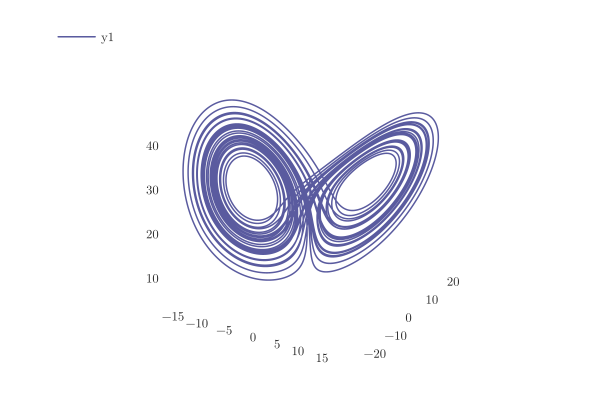

In [240]:
# Generate data for conditional sampling (not to be used for assimilation

Random.seed!(1234)

true_params = SVector(10., 28., 8/3)
sys_true = OdeSystem{3}("Perturbed Lorenz", u->f_lorenz(u; p=true_params), u->J_lorenz(u; p=true_params), (v,u)->Hv_lorenz(v, u; p=true_params))
sys = lorenz
Tλ = log(10)/0.9
u0 = @SVector [0.1, 0.1, ρ]

Tfλ = 16
nt = 2^15
@show h = Tfλ*Tλ / nt

stp = theta_method(0.5)
u = fill(u0 + 1e-1randn(SVector{3, Float64}), nt+1)

for i ∈ 1:nt
    u[i+1] = stp.Φ(u[i], h, sys_true)
end
plot(u)

# statistics
μ = mean(u)
Σ = cov(u)
A = √(Σ)
const x = 1
const y = 2
const z = 3
const yz = SVector(y,z)

# conditional statistics for u_yz
μ_z(x) = μ[] + Σ[z, xy]' * inv(Σ[xy, xy])*(SVector(x, y) - μ[xy])
σ_z(x) = Σ[z, z] - Σ[z, xy]'*inv(Σ[xy, xy])*Σ[xy, z]

sample_cond(x) = SVector(x, y, √(σ_z(x, y))*randn() + μ_z(x, y))
sample_cond(u) = sample_cond(u[1])

sample_naive(x::Number) = SVector(x, √(Σ[y, y])*randn() + μ[y], √(Σ[z, z])*randn() + μ[z])
sample_naive(u) = sample_naive(u[x])
sample_bad(u) = SVector(u[x], μ[y], μ[z])
sample_reallybad(u) = SVector(u[x], randn(), randn())
# sample_reallybad(u) = SVector(u[x], 0., 0.)

plot(u)

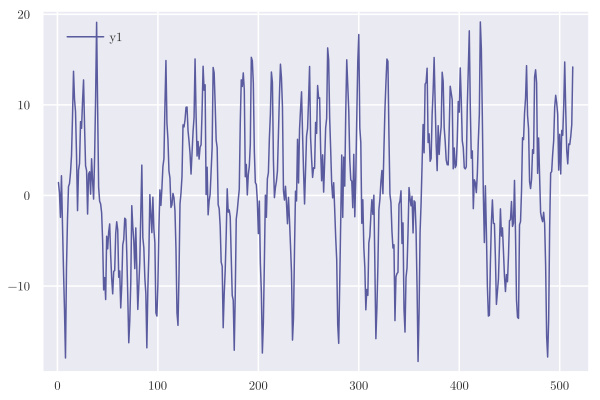

In [241]:
# generate data for assimilation
Random.seed!(1234)
u_complete = fill(u[end] + 1e-1randn(SVector{3, Float64}), nt+1)

for i ∈ 1:nt
    u_complete[i+1] = stp.Φ(u_complete[i], 1.0h, sys_true)
end

u_incomplete = [u[x] + 2randn() for u ∈ u_complete[1:2^6:end]]
plot(u_incomplete)

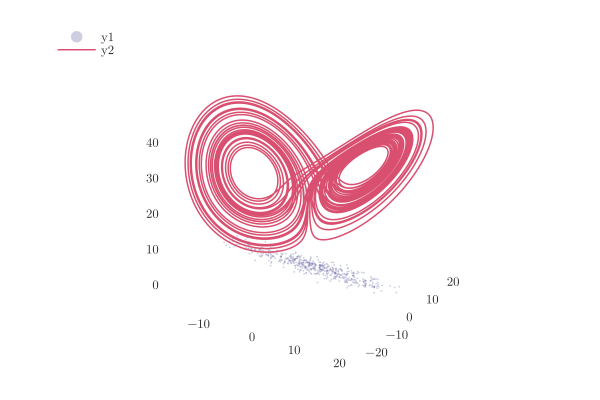

In [242]:
Random.seed!(1234)
# conditional sampling to generate initial guess for z
# u_recon = [sample_cond(v) for v ∈ u_incomplete]
# u_recon = [sample_naive(v) for v ∈ u_incomplete]
# u_recon = [sample_bad(v) for v ∈ u_incomplete]
u_recon = [sample_reallybad(v) for v ∈ u_incomplete]
# scatter(u_recon; scatter_args..., camera=(90, 90))
scatter(u_recon; scatter_args...)
plot!(u_complete)

In [243]:
# lsr
nl = 7
m = 2

orelax = 2 # controls the spacing of the red time points
           # when =1, red time points coincide with MGRIT C-points
           # when >1, relaxation is stronger but less parallel
α0 = 1e-5
weights = (5, 1., 1.)
W = SDiagonal(weights..., weights..., 1.)
relax_kwargs = (iters=2, overrelax=orelax, maxiters=1, weight=W)

function cycle(grids; relax_kwargs...)
    # regrid!(grids[1])
    down_cycle!(grids, lsr!; relax_kwargs...)
    lsr!(grids[end]; relax_kwargs...)
    # up_cycle!(grids, lsr!; relax_kwargs...)
    F_up!(grids, lsr!, 1; relax_kwargs...)
end

fg = TimeGrid(zero(u_complete), sys, stp, h, m)
grids = construct_hierarchy(fg, nl)
grids[end].u .= u_recon
# up_cycle!(grids, f_relax!)
# up_cycle!(grids, lsr!; relax_kwargs..., α=1e5)
F_up!(grids, lsr!; relax_kwargs..., α=1e5)

@show r0 = spacetimenorm(rel_residual(grids[1]))
r = r0
for k = 1:20
    isfinite(r) || break

    αk = max(α0, (1000r)^2)
    damping = 1.0 + 0.5max(0., tanh(-(2 + log10(r))))

    cycle(grids; relax_kwargs..., damping, α=αk)
    @show r = spacetimenorm(rel_residual(grids[1]))
end

r0 = spacetimenorm(rel_residual(grids[1])) = 0.0053607063078848155
r = spacetimenorm(rel_residual(grids[1])) = 0.002247635886706641
r = spacetimenorm(rel_residual(grids[1])) = 0.00022646472839316908
r = spacetimenorm(rel_residual(grids[1])) = 7.293902056639181e-5
r = spacetimenorm(rel_residual(grids[1])) = 4.735369016566167e-6
r = spacetimenorm(rel_residual(grids[1])) = 2.1525254839110556e-7
r = spacetimenorm(rel_residual(grids[1])) = 1.6864280347628725e-8
r = spacetimenorm(rel_residual(grids[1])) = 1.5561818227928599e-9
r = spacetimenorm(rel_residual(grids[1])) = 8.010725157237947e-11
r = spacetimenorm(rel_residual(grids[1])) = 1.8830492319268025e-12
r = spacetimenorm(rel_residual(grids[1])) = 1.6845651710770583e-13
r = spacetimenorm(rel_residual(grids[1])) = 1.1154892057688457e-14
r = spacetimenorm(rel_residual(grids[1])) = 3.668857006687289e-15
r = spacetimenorm(rel_residual(grids[1])) = 5.718537017360966e-16
r = spacetimenorm(rel_residual(grids[1])) = 5.352160303166227e-16
r = spac

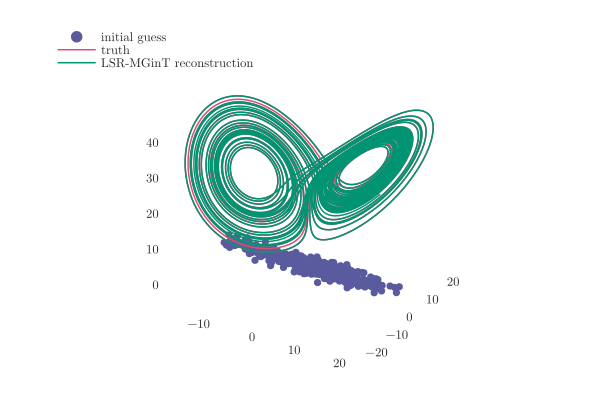

In [244]:
scatter(u_recon; label="initial guess")
plot!(u_complete; label="truth")
plot!(grids[1].u; label="LSR-MGinT reconstruction")

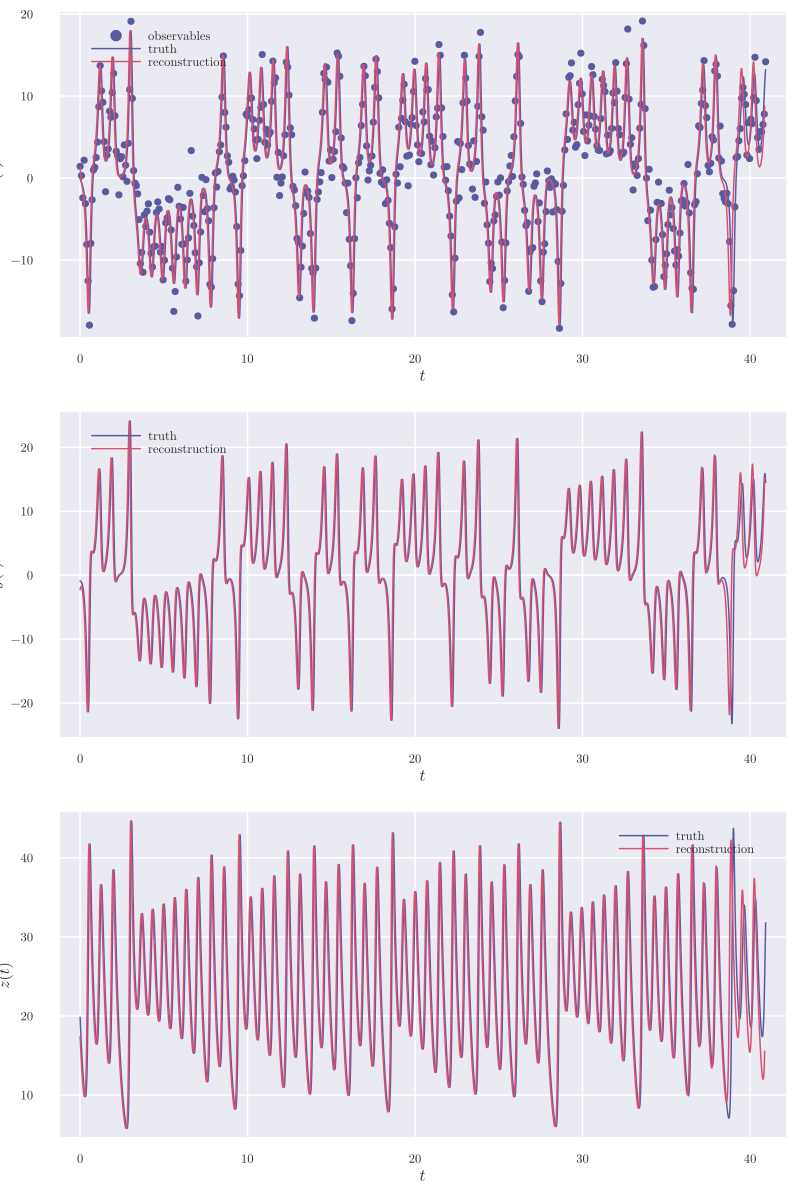

In [245]:
using LaTeXStrings
# pgfplotsx()

tc = [0., cumsum(dilate.(zero(grids[1].η[1:2^6:end]), 2^6*h))...]
t = [0., cumsum(dilate.(zero(grids[1].η), h))...]
td = [0., cumsum(dilate.(grids[1].η, h))...]

px = scatter(tc, u_incomplete; label="observables", color=1)
plot!(t, svectors2mat(u_complete)[x, :]; label="truth", color=1)
plot!(px, td, svectors2mat(grids[1].u)[x, :]; label="reconstruction", color=2)
plot!(px; xlabel=L"t", ylabel=L"x(t)")

py = plot(t, svectors2mat(u_complete)[y, :]; label="truth")
plot!(py, td, svectors2mat(grids[1].u)[y, :]; label="reconstruction")
plot!(py; xlabel=L"t", ylabel=L"y(t)")

pz = plot(t, svectors2mat(u_complete)[z, :]; label="truth", color=1)
plot!(pz, td, svectors2mat(grids[1].u)[z, :]; label="reconstruction", color=2)
plot!(pz; xlabel=L"t", ylabel=L"z(t)")

plot(px, py, pz; layout=(3, 1), size=(800, 1200))
# plot(px, pz; layout=(2, 1), size=(600, 600))
# savefig("data_assim.pdf")
# gr()